# 01 - EDA y Modelado
## Sistema actuarial de prediccion de riesgo y costo esperado en seguros de automovil

**Proyecto Integrador - Actuaria y Ciencia de Datos - Machine Learning + Streamlit**

Este notebook es el **expositor** del proyecto: recorre, de principio a fin y de
forma comentada, todo lo que se hizo. Sirve como guion para entender (y presentar)
el flujo completo:

1. Comprension del problema (negocio actuarial).
2. Exploracion de datos (EDA).
3. Limpieza de la base.
4. Preprocesamiento e ingenieria de variables (Pipeline / ColumnTransformer).
5. Modelado de **regresion** (costo esperado) y como se mejoro el R2.
6. Modelado de **clasificacion** (riesgo alto) y el manejo del desbalance.
7. Reduccion de dimensionalidad (PCA).
8. Demostracion del **simulador** (prediccion de una poliza nueva).
9. Como se conecta todo con la app de Streamlit.
10. Conclusiones y puntos de mejora.

> Clave del diseno: el **mismo** preprocesamiento se reutiliza en el notebook y
> en la app de Streamlit a traves del modulo `utils/preprocessing.py`. Asi se
> evita duplicar codigo y, sobre todo, se evitan **fugas de informacion**
> (data leakage), porque el pipeline se ajusta solo con datos de entrenamiento.

## 1. Comprension del problema

El objetivo de negocio es apoyar dos decisiones actuariales sobre una cartera de
polizas de auto:

- **Regresion** -> estimar `costo_esperado_anual_mxn`, el costo anual esperado de
  siniestros de cada poliza. Es la base para **tarificar** (poner la prima).
- **Clasificacion** -> predecir `riesgo_alto` (1 = riesgo alto). Solo ~15% de la
  cartera pertenece a esta clase, por lo que es un problema **desbalanceado**.
  Sirve para **segmentar** y gestionar la cartera.

Ambos objetivos se trabajan con el mismo conjunto de variables (caracteristicas
del conductor, del vehiculo y de la poliza/historial).

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # para importar utils desde notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

from utils import preprocessing as pp

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
print("Librerias cargadas. Modulo de preprocesamiento:", pp.__name__)

Librerias cargadas. Modulo de preprocesamiento: utils.preprocessing


## 2. Exploracion de datos (EDA)

Cargamos la base **original** (sin limpiar) para ver con que materia prima
partimos: dimensiones, tipos, faltantes y la forma de las variables objetivo.
La carga usa `encoding="utf-8-sig"` para eliminar el BOM inicial del CSV.

In [2]:
df = pp.cargar_datos("../data/seguro_auto_actuarial.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1500, 31)


,poliza_id,edad_conductor,sexo,estado_civil,nivel_estudios,ocupacion,zona_residencia,region,antiguedad_cliente_anios,ingreso_mensual_mxn,...,canal_venta,tiene_gps,asistencia_vial,mantenimiento_al_dia,dias_hasta_renovacion,puntaje_riesgo_zona,numero_siniestros_12m,costo_esperado_anual_mxn,riesgo_alto,clase_costo
0,POL-00001,46,Femenino,Soltero,Posgrado,Independiente,Urbana,Sur,9.4,7038.0,...,Agente,Si,Si,Si,170,74.7,0,3321,0,Bajo
1,POL-00002,38,Masculino,Casado,Licenciatura,Estudiante,Suburbana,Centro,0.9,19655.0,...,Agente,No,No,Si,100,57.4,0,7196,0,Medio
2,POL-00003,48,Masculino,Divorciado,Licenciatura,Empleado,Urbana,Centro,0.1,16140.0,...,Agente,No,No,Si,69,71.3,0,2046,0,Bajo
3,POL-00004,60,Femenino,Divorciado,Licenciatura,Empleado,Urbana,Sur,0.1,14954.0,...,Online,Si,No,No,173,83.4,0,1379,0,Bajo
4,POL-00005,37,Femenino,Soltero,Preparatoria,Empleado,Urbana,Centro,3.9,27192.0,...,Agente,Si,Si,No,188,73.6,1,11787,1,Alto


**Tipos y faltantes.** Esta tabla resume, por columna, el tipo de dato, cuantos
valores faltan (y su porcentaje) y cuantos valores unicos tiene. Es el primer
diagnostico de calidad del dato.

In [3]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "faltantes": df.isna().sum(),
    "%faltantes": (100*df.isna().mean()).round(1),
    "unicos": df.nunique(),
})
resumen

,tipo,faltantes,%faltantes,unicos
poliza_id,str,0,0.0,1500
edad_conductor,int64,0,0.0,58
sexo,str,0,0.0,3
estado_civil,str,0,0.0,4
nivel_estudios,str,0,0.0,4
ocupacion,str,81,5.4,6
zona_residencia,str,0,0.0,3
region,str,0,0.0,5
antiguedad_cliente_anios,float64,0,0.0,166
ingreso_mensual_mxn,float64,106,7.1,1358


**Balance de la clase objetivo.** La clase `riesgo_alto` esta desbalanceada:
la clase positiva (riesgo alto) ronda apenas el ~15%. Esto condiciona toda la
estrategia de clasificacion mas adelante.

riesgo_alto
0    0.85
1    0.15
Name: proportion, dtype: float64


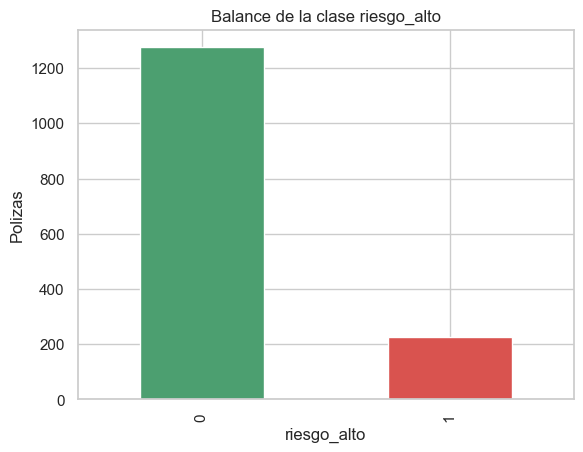

In [4]:
print(df["riesgo_alto"].value_counts(normalize=True).round(3))
df["riesgo_alto"].value_counts().plot(kind="bar", color=["#4c9f70", "#d9534f"])
plt.title("Balance de la clase riesgo_alto"); plt.ylabel("Polizas"); plt.show()

**Estadisticos de las variables numericas.** Permiten detectar escalas muy
distintas (que luego justifican el escalamiento) y valores extremos.

In [5]:
df[pp.NUMERIC_COLS_BASE].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
edad_conductor,1500.0,40.8,12.5,18.0,32.0,41.0,49.0,75.0
antiguedad_cliente_anios,1500.0,4.2,4.2,0.0,1.2,2.8,5.8,25.0
ingreso_mensual_mxn,1394.0,25895.4,19108.1,6000.0,15058.0,21511.5,31394.0,331506.0
score_crediticio,1415.0,651.3,74.5,401.0,602.0,651.0,700.0,850.0
prima_mensual_mxn,1500.0,637.2,412.2,350.0,350.0,479.0,723.2,3348.0
suma_asegurada_mxn,1500.0,332304.1,188926.7,109519.0,198807.2,279564.0,398534.8,1600000.0
deducible_pct,1500.0,6.9,3.5,3.0,5.0,5.0,10.0,15.0
historial_siniestros_3_anios,1500.0,0.5,0.7,0.0,0.0,0.0,1.0,5.0
km_anuales,1500.0,15598.7,5527.0,2500.0,11866.5,15601.0,19293.8,40135.0
edad_vehiculo_anios,1500.0,6.1,3.5,0.4,3.5,5.4,8.0,21.4


**El objetivo de regresion esta muy sesgado.** El costo anual tiene una cola
derecha enorme (asimetria > 7) por unos pocos **siniestros catastroficos**.
Estos outliers del objetivo son la causa principal del R2 bajo, como veremos en
la seccion de regresion.

Asimetria (skew): 7.36
min / mediana / max: 500 5570.5 131385
Percentil 99: 26505.0 | polizas con costo>30000: 10


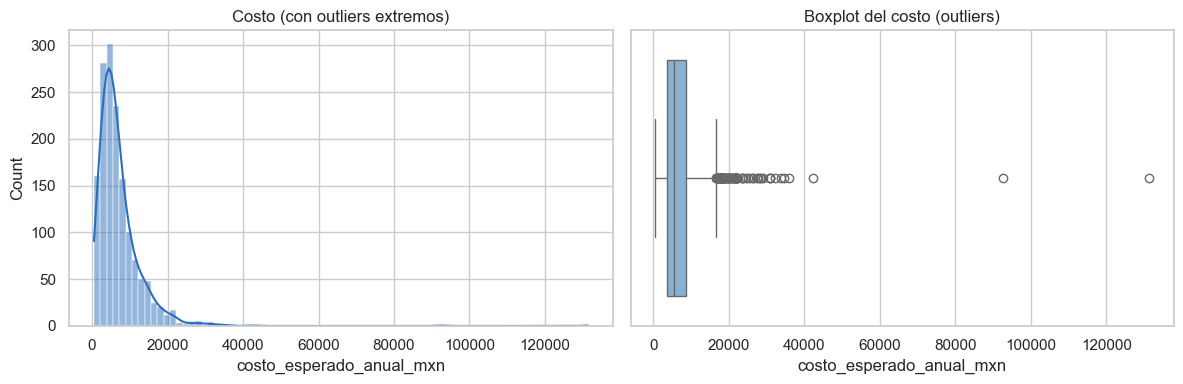

In [6]:
y_full = df["costo_esperado_anual_mxn"]
print("Asimetria (skew):", round(y_full.skew(), 2))
print("min / mediana / max:", y_full.min(), y_full.median(), y_full.max())
print("Percentil 99:", round(y_full.quantile(0.99), 0),
      "| polizas con costo>30000:", (y_full>30000).sum())
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_full, kde=True, ax=ax[0], color="#2c6fbb")
ax[0].set_title("Costo (con outliers extremos)")
sns.boxplot(x=y_full, ax=ax[1], color="#7bb3e0")
ax[1].set_title("Boxplot del costo (outliers)")
plt.tight_layout(); plt.show()

**Correlaciones.** El costo se explica sobre todo por la **suma asegurada** y el
**numero de siniestros**, seguidos de la **prima**. Esto sugiere una relacion de
tipo *frecuencia x severidad* (multiplicativa), que motivara las variables de
interaccion en el preprocesamiento.

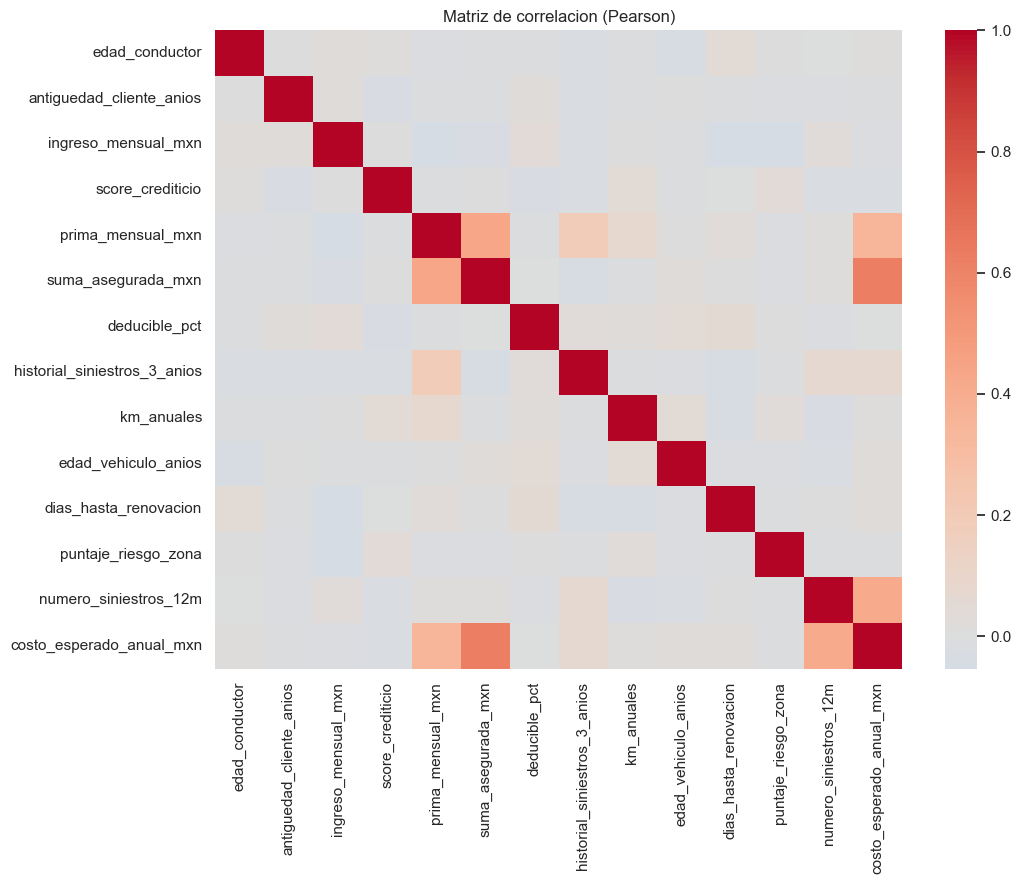

In [7]:
plt.figure(figsize=(11, 9))
sns.heatmap(df[pp.NUMERIC_COLS_BASE + ["costo_esperado_anual_mxn"]].corr(),
            cmap="coolwarm", center=0)
plt.title("Matriz de correlacion (Pearson)"); plt.tight_layout(); plt.show()

**Interpretacion del EDA.** Resumen de hallazgos:
- Hay **faltantes** en varias columnas (numericas y categoricas).
- `ingreso_mensual_mxn` y `prima_mensual_mxn` presentan **outliers**.
- La clase `riesgo_alto` esta **desbalanceada** (~15%).
- El **objetivo de regresion** tiene una **cola extrema** (asimetria > 7) por unos
  pocos siniestros catastroficos que conviene **acotar**.

## 3. Limpieza de la base

La limpieza la realiza el script `limpieza_datos.py` (se ejecuta una vez y genera
`data/seguro_auto_actuarial_limpio.csv`). Sus pasos son:

1. Lectura con `utf-8-sig` para quitar el **BOM**.
2. Eliminacion de **duplicados**.
3. Imputacion de **faltantes numericos** con la **mediana** (robusta a outliers).
4. Imputacion de **faltantes categoricos** con la etiqueta `"Desconocido"`
   (y la **moda** en binarias Si/No).
5. **Winsorizacion** de `ingreso_mensual_mxn` a los percentiles 1 y 99.
6. Creacion de **variables nuevas** (ingenieria de caracteristicas).

> Importante: ese CSV limpio es para **exploracion**. El **modelado NO** usa la
> imputacion/escalamiento "ya hechos": los repite **dentro de un Pipeline**
> ajustado solo con el train, para no filtrar informacion del test.

Abajo cargamos el CSV limpio solo para constatar que existe y comparar su forma.

In [8]:
df_limpio = pp.cargar_datos("../data/seguro_auto_actuarial_limpio.csv")
print("Original:", df.shape, "-> Limpio:", df_limpio.shape)
print("Faltantes totales en el limpio:", int(df_limpio.isna().sum().sum()))
df_limpio.head(3)

Original: (1500, 31) -> Limpio: (1500, 37)
Faltantes totales en el limpio: 0


,poliza_id,edad_conductor,sexo,estado_civil,nivel_estudios,ocupacion,zona_residencia,region,antiguedad_cliente_anios,ingreso_mensual_mxn,...,numero_siniestros_12m,costo_esperado_anual_mxn,riesgo_alto,clase_costo,km_por_anio_vehiculo,log_ingreso,ratio_prima_ingreso,siniestros_x_suma,siniestros_x_prima,grupo_edad
0,POL-00001,46,Femenino,Soltero,Posgrado,Independiente,Urbana,Sur,9.4,7038.0,...,0,3321,0,Bajo,1152.600000,8.859221,0.067055,0.0,0.0,Adulto
1,POL-00002,38,Masculino,Casado,Licenciatura,Estudiante,Suburbana,Centro,0.9,19655.0,...,0,7196,0,Medio,3813.829787,9.886138,0.056777,0.0,0.0,Adulto_joven
2,POL-00003,48,Masculino,Divorciado,Licenciatura,Empleado,Urbana,Centro,0.1,16140.0,...,0,2046,0,Bajo,3140.789474,9.689118,0.021684,0.0,0.0,Adulto


## 4. Preprocesamiento e ingenieria de variables

Aqui ocurren tres cosas:

1. **Ingenieria de variables** (`preparar_features`): interacciones
   `siniestros_x_suma` y `siniestros_x_prima` (frecuencia x exposicion), ratios,
   `log_ingreso`, `km_por_anio_vehiculo` y discretizacion de la edad en
   `grupo_edad`.
2. **Acotado del objetivo** (`acotar_costo`): el costo se recorta al **percentil
   99** (tratamiento de outliers del objetivo). Justificacion actuarial: los
   siniestros catastroficos se cubren con **reaseguro**, no con la tarifa normal.
3. **ColumnTransformer** (`construir_preprocesador`): imputacion + escalamiento de
   numericas, OneHotEncoder para nominales, OrdinalEncoder para ordinales. Se
   **excluye** `clase_costo` por ser una **fuga de informacion** (deriva del costo).

In [9]:
df_feat = pp.preparar_features(df)
X = df_feat[pp.columnas_features()]
y_reg = pp.acotar_costo(df_feat[pp.TARGET_REG])   # costo acotado al p99
y_clf = df_feat[pp.TARGET_CLF]
print("Variables nuevas:", pp.NUMERIC_COLS_ENGINEERED, "+ grupo_edad")
print("Tope del costo (p99):",
      round(df_feat[pp.TARGET_REG].quantile(pp.TARGET_CAP_QUANTILE), 0))
df_feat[["edad_conductor","grupo_edad","km_por_anio_vehiculo",
         "siniestros_x_suma","siniestros_x_prima"]].head()

Variables nuevas: ['km_por_anio_vehiculo', 'log_ingreso', 'ratio_prima_ingreso', 'siniestros_x_suma', 'siniestros_x_prima'] + grupo_edad
Tope del costo (p99): 26505.0


,edad_conductor,grupo_edad,km_por_anio_vehiculo,siniestros_x_suma,siniestros_x_prima
0,46,Adulto,1152.600000,0.0,0.0
1,38,Adulto_joven,3813.829787,0.0,0.0
2,48,Adulto,3140.789474,0.0,0.0
3,60,Mayor,1662.000000,0.0,0.0
4,37,Adulto_joven,2101.029412,298860.0,571.0


Al aplicar el `ColumnTransformer`, las variables categoricas se expanden (one-hot),
por lo que el numero de columnas crece respecto a las originales.

In [10]:
prep = pp.construir_preprocesador()
Xt = prep.fit_transform(X, y_clf)
print("Columnas originales:", len(pp.columnas_features()),
      "-> tras codificar:", Xt.shape[1])

Columnas originales: 33 -> tras codificar: 60


## 5. Modelado - Regresion (costo esperado)

### 5.1 El impacto de acotar el objetivo
Primero la prueba clave: **el mismo modelo lineal**, entrenado con el costo
**crudo** (con outliers) vs el costo **acotado al p99**. La diferencia en R2 y
RMSE demuestra que el cuello de botella eran los **outliers del objetivo**, no el
algoritmo.

In [11]:
y_crudo = df_feat[pp.TARGET_REG]
for etiqueta, y in [("Costo CRUDO (con outliers)", y_crudo),
                    ("Costo ACOTADO p99", y_reg)]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    pipe = Pipeline([("prep", pp.construir_preprocesador()), ("m", LinearRegression())])
    pipe.fit(Xtr, ytr); p = pipe.predict(Xte)
    print(f"{etiqueta:28s} R2={r2_score(yte,p):.3f}  RMSE={np.sqrt(mean_squared_error(yte,p)):.0f}")

Costo CRUDO (con outliers)   R2=0.413  RMSE=6933


Costo ACOTADO p99            R2=0.753  RMSE=2626


### 5.2 Comparacion de modelos
Comparamos cinco modelos de regresion sobre el objetivo **ya acotado**. Reportamos
MAE, RMSE y R2 sobre el conjunto de prueba (`random_state=42`).

In [12]:
Xtr, Xte, ytr, yte = train_test_split(X, y_reg, test_size=0.2, random_state=RANDOM_STATE)

modelos_reg = {
    "Lineal": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=10.0, max_iter=10000),
    "Arbol": DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                                          max_features=0.5, n_jobs=-1, random_state=RANDOM_STATE),
}
filas, pipes_reg = [], {}
for nombre, m in modelos_reg.items():
    pipe = Pipeline([("prep", pp.construir_preprocesador()), ("model", m)])
    pipe.fit(Xtr, ytr); pred = pipe.predict(Xte)
    filas.append({"Modelo": nombre,
                  "MAE": mean_absolute_error(yte, pred),
                  "RMSE": np.sqrt(mean_squared_error(yte, pred)),
                  "R2": r2_score(yte, pred)})
    pipes_reg[nombre] = pipe
pd.DataFrame(filas).set_index("Modelo").round(3)

,MAE,RMSE,R2
Modelo,,,
Lineal,1656.494,2625.696,0.753
Ridge,1655.481,2626.097,0.753
Lasso,1629.764,2603.421,0.757
Arbol,1900.111,2959.037,0.686
RandomForest,1764.703,2726.777,0.733


### 5.3 Interpretacion: coeficientes del modelo lineal
Los coeficientes (sobre variables ya escaladas) indican que variables empujan el
costo hacia arriba o abajo. Las interacciones frecuencia x exposicion aparecen
entre las mas influyentes, confirmando la intuicion actuarial.

In [13]:
lin = pipes_reg["Lineal"]
nombres = pp.nombres_features_transformadas(lin.named_steps["prep"])
coefs = lin.named_steps["model"].coef_
serie = pd.Series(coefs, index=nombres).sort_values(key=np.abs, ascending=False)
serie.head(10)

suma_asegurada_mxn              2910.154769
numero_siniestros_12m           2157.336825
tipo_vehiculo_Deportivo          672.494534
historial_siniestros_3_anios     496.220300
km_por_anio_vehiculo             413.480769
tipo_vehiculo_Compacto          -398.194789
tipo_vehiculo_Sedan             -387.123972
asistencia_vial                 -350.633577
segmento_marca                   345.149246
estado_civil_Viudo              -310.454081
dtype: float64

### 5.4 Importancia de variables (Random Forest)
Vision no lineal de la importancia: el bosque aleatorio confirma a `suma_asegurada`,
`numero_siniestros` y sus interacciones como los principales motores del costo.

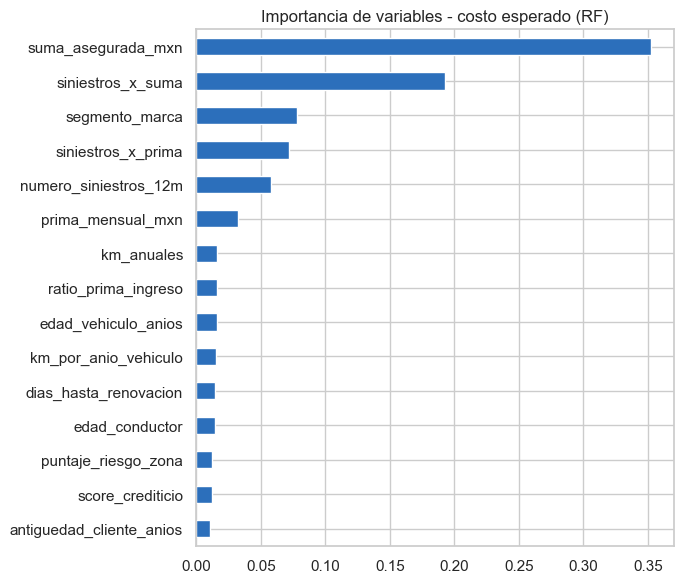

In [14]:
rf = pipes_reg["RandomForest"]
imp = pd.Series(rf.named_steps["model"].feature_importances_,
                index=pp.nombres_features_transformadas(rf.named_steps["prep"]))
imp.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(7,6), color="#2c6fbb")
plt.title("Importancia de variables - costo esperado (RF)"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

## 6. Modelado - Clasificacion (riesgo alto)

Por el desbalance (~15%), la **accuracy** es engañosa: un modelo que prediga
siempre "normal" acierta ~85% pero no detecta a nadie. Por eso:
- Usamos `class_weight="balanced"` para penalizar mas los errores en la clase
  minoritaria.
- Priorizamos **recall** y **F1**, no la accuracy.

In [15]:
Xtr, Xte, ytr, yte = train_test_split(X, y_clf, test_size=0.2,
                                      random_state=RANDOM_STATE, stratify=y_clf)
modelos_clf = {
    "Logistica": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Arbol": DecisionTreeClassifier(max_depth=6, min_samples_leaf=20,
                                    class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                           class_weight="balanced", n_jobs=-1,
                                           random_state=RANDOM_STATE),
}
filas, pipes_clf = [], {}
for nombre, m in modelos_clf.items():
    pipe = Pipeline([("prep", pp.construir_preprocesador()), ("model", m)])
    pipe.fit(Xtr, ytr); pred = pipe.predict(Xte)
    filas.append({"Modelo": nombre,
                  "Accuracy": accuracy_score(yte, pred),
                  "Precision": precision_score(yte, pred, zero_division=0),
                  "Recall": recall_score(yte, pred, zero_division=0),
                  "F1": f1_score(yte, pred, zero_division=0)})
    pipes_clf[nombre] = pipe
pd.DataFrame(filas).set_index("Modelo").round(3)

,Accuracy,Precision,Recall,F1
Modelo,,,,
Logistica,0.897,0.603,0.911,0.726
Arbol,0.907,0.649,0.822,0.725
RandomForest,0.900,0.627,0.822,0.712


### Matriz de confusion
La matriz separa los cuatro casos. En seguros lo mas costoso son los **falsos
negativos** (riesgos altos no detectados, esquina que queremos minimizar).

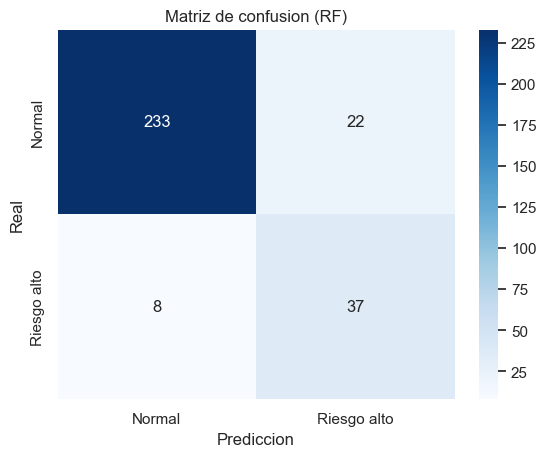

              precision    recall  f1-score   support

           0       0.97      0.91      0.94       255
           1       0.63      0.82      0.71        45

    accuracy                           0.90       300
   macro avg       0.80      0.87      0.83       300
weighted avg       0.92      0.90      0.91       300



In [16]:
rf = pipes_clf["RandomForest"]; pred = rf.predict(Xte)
cm = confusion_matrix(yte, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Riesgo alto"], yticklabels=["Normal","Riesgo alto"])
plt.title("Matriz de confusion (RF)"); plt.xlabel("Prediccion"); plt.ylabel("Real"); plt.show()
print(classification_report(yte, pred))

## 7. Reduccion de dimensionalidad (PCA)

PCA se usa como herramienta de **visualizacion**: proyecta todas las variables a
2 componentes para ver si las clases de riesgo se separan. No es el modelo final,
pero ayuda a intuir la estructura de los datos.

Varianza explicada: [0.108 0.093] | acumulada: 0.201


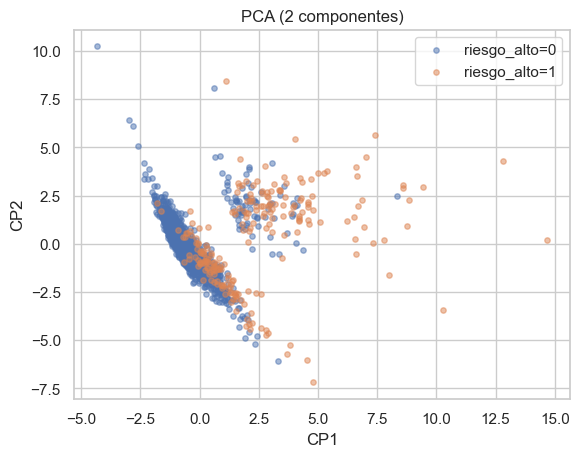

In [17]:
prep = pp.construir_preprocesador()
Xt = prep.fit_transform(X, y_clf)
if hasattr(Xt, "toarray"): Xt = Xt.toarray()
pca = PCA(n_components=2, random_state=RANDOM_STATE)
comp = pca.fit_transform(Xt)
print("Varianza explicada:", pca.explained_variance_ratio_.round(3),
      "| acumulada:", pca.explained_variance_ratio_.sum().round(3))
for v in [0,1]:
    mask = y_clf.values==v
    plt.scatter(comp[mask,0], comp[mask,1], s=15, alpha=0.5, label=f"riesgo_alto={v}")
plt.legend(); plt.title("PCA (2 componentes)"); plt.xlabel("CP1"); plt.ylabel("CP2"); plt.show()

## 8. Demostracion del simulador

El simulador de la app hace exactamente esto: dada una poliza, aplica el **mismo**
preprocesamiento y usa el **mejor modelo de regresion** (Lasso) para el costo y el
**mejor de clasificacion** (Regresion logistica) para el riesgo. La probabilidad
de riesgo se compara contra un **umbral** ajustable (por defecto 0.50).

Aqui lo reproducimos tomando una poliza de ejemplo del propio dataset.

In [18]:
mejor_reg = pipes_reg["Lasso"]
mejor_clf = pipes_clf["Logistica"]

# Poliza de ejemplo (una fila del set de caracteristicas)
ejemplo = X.iloc[[0]]
costo_pred = float(mejor_reg.predict(ejemplo)[0])
proba = float(mejor_clf.predict_proba(ejemplo)[0, 1])
umbral = 0.50
clase = "RIESGO ALTO" if proba >= umbral else "Riesgo normal"

print("--- Resultado del simulador (poliza de ejemplo) ---")
print(f"Costo esperado anual estimado : {costo_pred:,.0f} MXN")
print(f"Probabilidad de riesgo alto   : {proba*100:.1f}%")
print(f"Clasificacion (umbral {umbral:.2f}) : {clase}")

--- Resultado del simulador (poliza de ejemplo) ---
Costo esperado anual estimado : 2,128 MXN
Probabilidad de riesgo alto   : 0.2%
Clasificacion (umbral 0.50) : Riesgo normal


## 9. Como se conecta todo con la app de Streamlit

El proyecto esta modularizado para que el notebook, los scripts y la app
**compartan la misma logica**:

| Archivo | Rol |
|---|---|
| `utils/preprocessing.py` | Fuente unica de verdad: carga, ingenieria de variables, acotado del objetivo y `ColumnTransformer`. Lo usan el notebook, el entrenamiento y la app. |
| `utils/plots.py` | Graficas reutilizables. |
| `limpieza_datos.py` | Genera el CSV limpio (seccion 3). |
| `entrenar_modelos.py` | Entrena y guarda los modelos (`models/*.joblib`). |
| `app.py` | Interfaz Streamlit; **carga** los modelos ya entrenados (no reentrena). |
| `notebooks/01_eda_modelado.ipynb` | Este expositor del flujo completo. |

Asi, lo que se valida aqui (EDA, acotado, modelos, simulador) es **identico** a lo
que corre en la app, evitando duplicar codigo y fugas de informacion.

## 10. Conclusiones y puntos de mejora

**Conclusiones**
- El R2 del costo estaba limitado por ~10 **siniestros catastroficos**; al acotarlos
  al percentil 99 y anadir interacciones (`siniestros_x_suma`, `siniestros_x_prima`)
  el **R2 pasa de ~0.42 a ~0.75**.
- Los modelos lineales y de **Random Forest** quedan muy parejos; los lineales aportan
  interpretabilidad y los de arboles capturan no linealidades.
- En clasificacion, el balanceo de clases mejora el **recall** de la clase de riesgo
  alto, clave para el negocio asegurador.

**Puntos de mejora**
- Ajuste de hiperparametros (GridSearchCV) y validacion cruzada.
- Modelado actuarial fino: GLM Tweedie o separar frecuencia (Poisson) y severidad (Gamma).
- Balanceo con SMOTE y **calibracion** de probabilidades; optimizar el umbral por costo.
- Analisis de **equidad** (fairness) por subgrupos y explicabilidad (SHAP).
- Validar con **datos reales** (la base es sintetica) antes de cualquier uso productivo.

> **Etica:** variables sensibles (`sexo`, `region`, `ocupacion`) pueden inducir
> sesgos y requieren validacion y auditoria antes de cualquier uso real.